In [50]:
import os
from tqdm.auto import tqdm

import numpy as np
import pandas as pd
from scipy import stats

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import sklearn.metrics as metrics

import matplotlib.pyplot as plt
import seaborn as sns

Download the dataset (TMDB_movie_dataset_v11.csv) and put it in the 'data' folder in the same directory as this file.

In [51]:
raw_data = pd.read_csv('data/TMDB_movie_dataset_v11.csv', header=0)

Select only sci-fi and fantasy films that have a listed non-zero budget, revenue, and run time

In [52]:
#print(list(raw_data.columns))
raw_data = raw_data.sort_values(by='id')
raw_data['genres'] = raw_data['genres'].fillna('')
sf_data = raw_data[raw_data['genres'].apply(lambda x: ('Science Fiction' in x) or ('Fantasy' in x))]
sf_data = sf_data.dropna(subset=['budget', 'revenue', 'runtime'], how='any')
sf_data = sf_data[sf_data['revenue'].apply(lambda x: x != 0)]
sf_data = sf_data[sf_data['budget'].apply(lambda x: x != 0)]
sf_data = sf_data[sf_data['runtime'].apply(lambda x: x != 0)]
#print(sf_data.shape)


Break the filtered dataset in to X and Y sets

In [64]:
x_data = sf_data[['budget','runtime']].reset_index(drop=True)
y_data = sf_data[['revenue']].reset_index(drop=True)

x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.2, random_state=69)

scaler = StandardScaler()
x_train_s = scaler.fit_transform(x_train)
x_test_s = scaler.transform(x_test)
#print(x_train_s.shape)
#print(x_test_s.shape)
#print(y_train_s.shape)
#print(y_test_s.shape)

Perform PCA

In [65]:
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_train_s)
print(f"Percent variation explaied by {x_data.columns[0]}: {pca.explained_variance_ratio_[0]*100}")
print(f"Percent variation explaied by {x_data.columns[1]}: {pca.explained_variance_ratio_[1]*100}")

Percent variation explaied by budget: 61.442183226152316
Percent variation explaied by runtime: 38.557816773847684


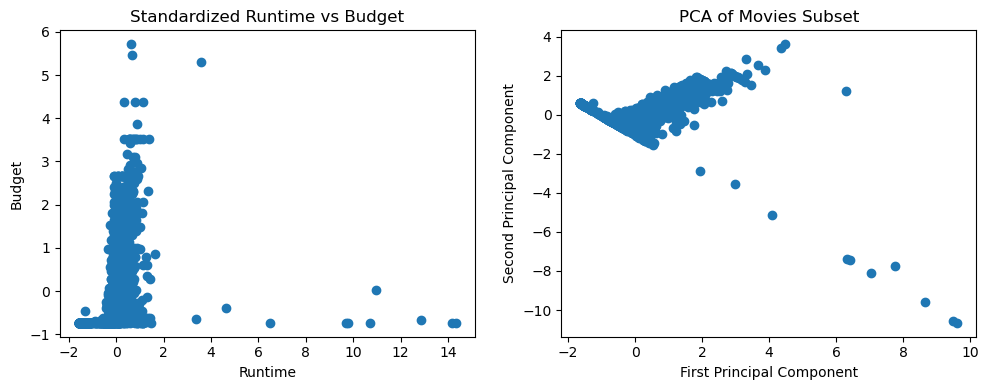

In [66]:
fig, axs = plt.subplots(1, 2, figsize=(10,4))

axs[0].scatter(x_train_s[:, 1], x_train_s[:, 0])
axs[0].set_xlabel('Runtime')
axs[0].set_ylabel('Budget')
axs[0].set_title('Standardized Runtime vs Budget')

axs[1].scatter(x_pca[:, 0], x_pca[:, 1])
axs[1].set_xlabel('First Principal Component')
axs[1].set_ylabel('Second Principal Component')
axs[1].set_title('PCA of Movies Subset')
fig.tight_layout()

(2060, 24)
Percent variation explaied by budget: 71.38615073142793
Percent variation explaied by runtime: 28.613849268572068


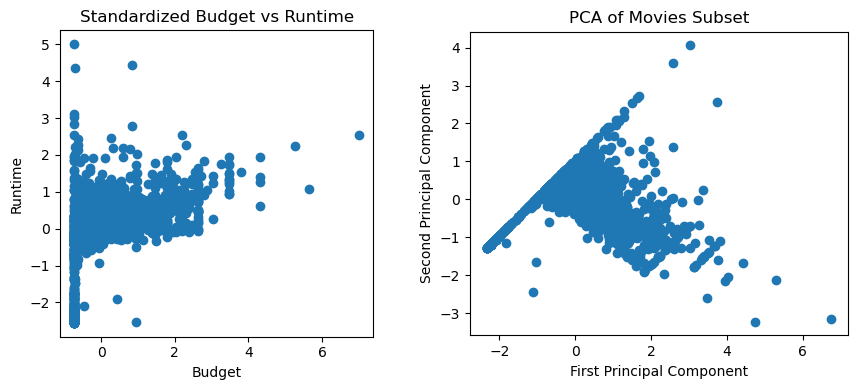

In [82]:
#lrt = limited runtime
sf_data_lrt = sf_data[sf_data['runtime'].apply(lambda x: x<=300)]

print(sf_data_lrt.shape)

x_data_lrt = sf_data_lrt[['budget','runtime']].reset_index(drop=True)
y_data_lrt = sf_data_lrt[['revenue']].reset_index(drop=True)

x_train_lrt, x_test_lrt, y_train_lrt, y_test_lrt = train_test_split(x_data_lrt, y_data_lrt, test_size=0.2, random_state=69)

scaler = StandardScaler()
x_train_lrt_s = scaler.fit_transform(x_train_lrt)
x_test_lrt_s = scaler.transform(x_test_lrt)

pca = PCA(n_components=2)
x_pca_lrt = pca.fit_transform(x_train_lrt_s)
print(f"Percent variation explaied by {x_data_lrt.columns[0]}: {pca.explained_variance_ratio_[0]*100}")
print(f"Percent variation explaied by {x_data_lrt.columns[1]}: {pca.explained_variance_ratio_[1]*100}")

fig, axs = plt.subplots(1, 2, figsize=(9,4))

axs[0].scatter(x_train_lrt_s[:, 0], x_train_lrt_s[:, 1])
axs[0].set_xlabel('Budget')
axs[0].set_ylabel('Runtime')
axs[0].set_title('Standardized Budget vs Runtime')
axs[0].set_aspect('equal')

axs[1].scatter(x_pca_lrt[:, 0], x_pca_lrt[:, 1])
axs[1].set_xlabel('First Principal Component')
axs[1].set_ylabel('Second Principal Component')
axs[1].set_title('PCA of Movies Subset')
axs[1].set_aspect('equal')

fig.tight_layout()